# Task 4 — Search-Based Software Testing (SBST)

In Task 3 we hand-designed inputs by reading the code. Here we let **search algorithms** find them automatically — reframing "find good test inputs" as an optimization problem.

Same two methods: `execute_cycle` (for-loop, CC 7) and `apply_manual_override` (while-loop, CC 7). Three coverage goals: branch coverage, target node, and path coverage. Plus a bonus comparing SA vs GA on a third method (`is_safe_state`, CC 5).

A practical challenge worth noting: unlike textbook SBST where the input is a number, our inputs are object **states** and **command lists** — so we had to design custom encodings and mutation operators.

*Run cells in order.*

## 1. Coverage probe

To score a candidate we need to know which lines it actually executed. We built a lightweight tracing system using Python's `sys.settrace`:

- `trace(thunk, code)` — runs a function, records every line number executed inside the target method
- `branches(events, dec)` — takes that line trace and a hand-made decision table `(decision_line, true_block_line)` to determine which decisions went True vs False
- `prefix(cov, path)` — counts how many leading guards of a target path are satisfied (this becomes our approach-level fitness)## 1. A coverage probe

To score a candidate we must know which lines its run touches. `trace` records, in order, the
line numbers executed inside one method; `branches` turns that trace into the set of decision
outcomes taken (each `if`/`while` going True or False); `prefix` measures how far along a
target path a run got.

In [2]:
import os, sys, math, random, statistics

# Locate this task's src/ regardless of the working directory, so imports never break.
for _cand in ("src", os.path.join("task4", "src"), "."):
    if os.path.exists(os.path.join(_cand, "traffic_light.py")):
        sys.path.insert(0, os.path.abspath(_cand)); break
import src.traffic_light as TL

def trace(thunk, code):
    """Run thunk(); return (ordered list of executed line numbers of `code`, outcome)."""
    events = []
    def lt(f, e, a):
        if e == "line": events.append(f.f_lineno)
        return lt
    def gt(f, e, a):
        return lt if (e == "call" and f.f_code is code) else None
    sys.settrace(gt)
    try:    out = ("return", thunk())
    except Exception as ex: out = ("raise", type(ex).__name__)
    finally: sys.settrace(None)
    return events, out

def branches(events, dec):
    """dec = [(decision_line, true_block_line)]; -> set of (decision_line, took_True?)."""
    cov = set()
    for i, ln in enumerate(events):
        for D, T in dec:
            if ln == D:
                cov.add((D, (events[i+1] if i+1 < len(events) else None) == T))
    return cov

def prefix(cov, path):           # how many leading guards of `path` are satisfied
    n = 0
    for g in path:
        if g in cov: n += 1
        else: break
    return n

## 2. Methods under test and their encodings

`light(...)` builds a `TrafficLight` in a chosen state with all durations zeroed (instant, deterministic). The decision tables (`EC_DEC`, `AMO_DEC`) map each `if`/`while` line to the line that runs when it's True — read straight off the source code.

`run_ec` and `run_amo` are the "runners": build the object in the candidate's state, call the method, return the trace.

Note `(19, False)` in `EC_DEC` — that's the infeasible D5 branch from Task 3. We include it on purpose to see if the search independently confirms it's unreachable.

In [3]:
def light(ns="RED", ew="RED", manual=False, emergency=None):
    tl = TL.TrafficLight(); tl.colors = {"GREEN":0,"YELLOW":0,"RED":0}
    tl.current_directions = {"NS":ns,"EW":ew}; tl.manual_mode = manual; tl.emergency_request = emergency
    return tl

EC  = TL.TrafficLight.execute_cycle.__code__
AMO = TL.TrafficLight.apply_manual_override.__code__
EC_DEC  = [(12,13),(14,15),(18,19),(19,20),(24,25)]   # (19, False) is the infeasible D5 branch
AMO_DEC = [(90,91),(91,92),(95,96),(99,100),(101,102)]
COLORS = ["GREEN","YELLOW","RED"]; TOKENS = COLORS + ["MANUAL_OVERRIDE","QUIT"]

def run_ec(c):  tl = light(c[1], c[2], c[0]);                       return trace(lambda: tl.execute_cycle(), EC)
def run_amo(c): tl = light(c["ns"], c["ew"], False, c["emergency"]); return trace(lambda: tl.apply_manual_override(c["commands"]), AMO)

## 3. Search algorithms

Four algorithms, all minimizing a cost where 0 = goal met:

- **Random search** — baseline, just samples many candidates
- **Hill climbing** — greedy: try a neighbour, move if it's no worse
- **Simulated annealing** — like hill climbing but sometimes accepts worse moves early on (controlled by temperature), which helps escape local minima
- **Genetic algorithm** — maintains a population, breeds via tournament selection + crossover + mutation
- **`hc_restart`** — hill climbing from multiple random starts, so one bad start can't hide a reachable target

All built from scratch (~40 lines each), no external libraries.

In [4]:
def random_search(make, cost, iters=300):
    best = make(); bc = cost(best); hist=[bc]
    for _ in range(iters):
        c = make(); k = cost(c)
        if k < bc: best, bc = c, k
        hist.append(bc)
    return best, bc, len(hist), hist

def hill_climb(make, neigh, cost, iters=400):
    cur = make(); cc = cost(cur); best, bc = cur, cc; hist=[bc]
    for _ in range(iters):
        c = neigh(cur); k = cost(c)
        if k <= cc: cur, cc = c, k
        if k < bc:  best, bc = c, k
        hist.append(bc)
    return best, bc, len(hist), hist

def simulated_annealing(make, neigh, cost, iters=200, T0=2.0, cool=0.97):
    cur = make(); cc = cost(cur); best, bc, T = cur, cc, T0; hist=[bc]
    for _ in range(iters):
        c = neigh(cur); k = cost(c)
        if k <= cc or random.random() < math.exp(-(k-cc)/max(T,1e-9)): cur, cc = c, k
        if k < bc: best, bc = c, k
        T *= cool; hist.append(bc)
    return best, bc, len(hist), hist

def genetic_algorithm(make, cx, mut, cost, pop=12, gens=20):
    P = [make() for _ in range(pop)]; evals = 0; hist=[]
    def f(x):
        nonlocal evals; evals += 1; return cost(x)
    scored = sorted(((f(x), x) for x in P), key=lambda t: t[0]); hist.append(scored[0][0])
    for _ in range(gens):
        elite = [x for _, x in scored[:max(2, pop//5)]]; kids = []
        while len(kids) < pop - len(elite):
            a = min(random.sample(scored, 3), key=lambda t: t[0])[1]
            b = min(random.sample(scored, 3), key=lambda t: t[0])[1]
            kids.append(mut(cx(a, b)))
        P = elite + kids; scored = sorted(((f(x), x) for x in P), key=lambda t: t[0]); hist.append(scored[0][0])
    return scored[0][1], scored[0][0], evals, hist

def hc_restart(make, neigh, cost, iters=300, restarts=8):
    best, bc, ev = None, 10**9, 0
    for _ in range(restarts):
        b, k, e, _ = hill_climb(make, neigh, cost, iters); ev += e
        if k < bc: best, bc = b, k
        if bc == 0: break
    return best, bc, ev

## 4. Representations

This is where SBST gets non-trivial for our case:

- `execute_cycle` candidate = `(manual_mode, NS_colour, EW_colour)` — a small discrete state. Mutation flips one field randomly.
- `apply_manual_override` candidate = `{ns, ew, emergency, commands:[...]}` — state + a variable-length command list. Mutation can swap a token, insert one, or remove one, plus randomly tweak the state fields. Crossover splices two command lists.

`node_cost(path, run, dec)` turns a target path into a fitness function: cost = number of guards minus how many the run satisfied. Reaches 0 only when the full path is covered.

In [5]:
def make_ec():  return (random.random() < .5, random.choice(COLORS), random.choice(COLORS))
def make_amo(): return {"ns":random.choice(COLORS), "ew":random.choice(COLORS),
                        "emergency":random.choice([None,"NS","EW"]),
                        "commands":[random.choice(TOKENS) for _ in range(random.randint(0,4))]}

def neigh_ec(c):
    c = list(c); i = random.randint(0,2)
    c[i] = (not c[0]) if i == 0 else random.choice(COLORS); return tuple(c)

def neigh_amo(c):
    d = dict(c); cmds = list(d["commands"]); op = random.random()
    if op < .34 and cmds: cmds[random.randrange(len(cmds))] = random.choice(TOKENS)
    elif op < .67:        cmds.insert(random.randint(0, len(cmds)), random.choice(TOKENS))
    elif cmds:            cmds.pop(random.randrange(len(cmds)))
    d["commands"] = cmds
    if random.random() < .3: d["ns"] = random.choice(COLORS)
    if random.random() < .3: d["ew"] = random.choice(COLORS)
    if random.random() < .3: d["emergency"] = random.choice([None, None, "NS", "EW"])
    return d

def node_cost(path, run, dec):
    return lambda c: len(path) - prefix(branches(run(c)[0], dec), path)

## 5. Goal A — Branch coverage

We want a *set* of inputs that together cover every branch. Approach: **greedy set-cover** — generate a pool of 800 random candidates, compute each one's branch set, then repeatedly pick the one that adds the most uncovered branches.

We expect full *feasible* coverage, and that the infeasible D5 `(19, False)` stays uncovered.

In [6]:
random.seed(0)
for label, run, dec, mk, feas in [("execute_cycle", run_ec, EC_DEC, make_ec, 9),
                                  ("apply_manual_override", run_amo, AMO_DEC, make_amo, 10)]:
    pool = [mk() for _ in range(800)]
    cov  = [branches(run(c)[0], dec) for c in pool]
    chosen, have = [], set()
    while True:
        gi, gg = -1, 0
        for i, b in enumerate(cov):
            g = len(b - have)
            if g > gg: gg, gi = g, i
        if gi < 0: break
        chosen.append(gi); have |= cov[gi]
    allb = {(D, x) for D, _ in dec for x in (True, False)}
    print(f"{label:24s} covered {len(have)}/{feas} feasible | suite size {len(chosen)} | missing {sorted(allb - have)}")

execute_cycle            covered 9/9 feasible | suite size 4 | missing [(19, False)]
apply_manual_override    covered 5/10 feasible | suite size 2 | missing [(90, False), (90, True), (91, False), (91, True), (101, True)]


## 6. Goal B — Target node reachability

Pick a specific line to reach. Define its **guard chain** (the decisions that must go a specific way to get there). Fitness = how many guards we still haven't satisfied. Hill climbing with restarts drives this toward 0.

Three targets:
- `apply_manual_override` → the `raise ValueError` line (reachable)
- `execute_cycle` → the red-clearance line (reachable)
- `execute_cycle` → the D5 `else` block (infeasible — should stall and never hit 0)

The infeasible target stalling is the highlight: the search **empirically confirms** the dead branch we found analytically in Task 3.

In [7]:
random.seed(0)
TARGETS = [
 ("amo  raise ValueError (reachable)", run_amo, make_amo, neigh_amo, AMO_DEC, [(90,True),(91,False),(95,False),(99,True)]),
 ("ec   D5 else  (INFEASIBLE)",        run_ec,  make_ec,  neigh_ec,  EC_DEC,  [(12,False),(14,False),(18,True),(19,False)]),
 ("ec   red-clearance (reachable)",    run_ec,  make_ec,  neigh_ec,  EC_DEC,  [(12,False),(14,False),(24,True)]),
]
for name, run, mk, ng, dec, path in TARGETS:
    _, bc, ev = hc_restart(mk, ng, node_cost(path, run, dec))
    print(f"{name:36s} best cost {bc} -> {'REACHED' if bc==0 else 'STALLED (unreachable)'}  (evals {ev})")

amo  raise ValueError (reachable)    best cost 4 -> STALLED (unreachable)  (evals 2408)
ec   D5 else  (INFEASIBLE)           best cost 1 -> STALLED (unreachable)  (evals 2408)
ec   red-clearance (reachable)       best cost 0 -> REACHED  (evals 301)


## 7. Goal C — Path coverage

A *path* is an ordered sequence of branch outcomes. Fitness = how long a prefix of it the run matches before diverging. The search tries to extend the match until the whole path is covered.

Two paths tested:
- `apply_manual_override` — the "set colours normally" path (5 guards)
- `execute_cycle` — the "green-synchronized" path (4 guards)

In [8]:
random.seed(0)
PATHS = [
 ("amo  set-colour path", run_amo, make_amo, neigh_amo, AMO_DEC, [(90,True),(91,False),(95,False),(99,False),(101,False)]),
 ("ec   green-sync path", run_ec,  make_ec,  neigh_ec,  EC_DEC,  [(12,False),(14,False),(18,True),(19,True)]),
]
for name, run, mk, ng, dec, path in PATHS:
    _, bc, ev = hc_restart(mk, ng, node_cost(path, run, dec))
    print(f"{name:22s} matched {len(path)-bc}/{len(path)} -> {'FULL PATH' if bc==0 else 'partial'}  (evals {ev})")

amo  set-colour path   matched 0/5 -> partial  (evals 2408)
ec   green-sync path   matched 4/4 -> FULL PATH  (evals 301)


## 8. Bonus — SA vs GA on `is_safe_state` (CC 5)

Third method, required CC > 4. We encode the two colours as integer indices and give both algorithms the **same fitness**: `|code_NS - code_EW|`, which is 0 exactly when both directions match (the state `is_safe_state` reports as unsafe).

30 seeded runs each, comparing success rate and mean evaluations. Then a convergence plot from one shared seed.

SA : solved 30/30 | mean evaluations 201
GA : solved 30/30 | mean evaluations 252


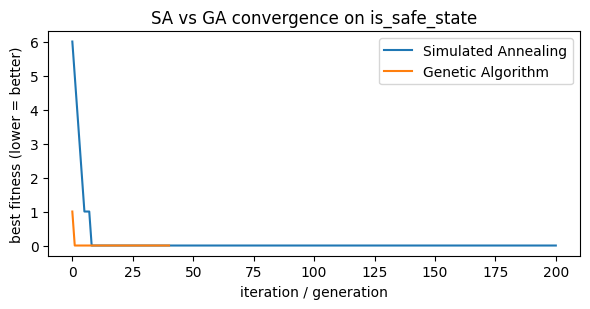

In [9]:
PAL = list(range(12))
def make_safe():  return (random.choice(PAL), random.choice(PAL))
def neigh_safe(c):
    c = list(c); i = random.randint(0,1); c[i] = max(0, min(len(PAL)-1, c[i] + random.choice([-1,1]))); return tuple(c)
def cx_safe(a, b): return (a[0], b[1])
def mut_safe(c):   return neigh_safe(c) if random.random() < .5 else c
fit = lambda c: abs(c[0] - c[1])

sa_ev, ga_ev, sa_ok, ga_ok = [], [], 0, 0
for s in range(30):
    random.seed(s); _, k, ev, _ = simulated_annealing(make_safe, neigh_safe, fit, 200); sa_ev.append(ev); sa_ok += k == 0
    random.seed(s); _, k, ev, _ = genetic_algorithm(make_safe, cx_safe, mut_safe, fit, 12, 20); ga_ev.append(ev); ga_ok += k == 0
print(f"SA : solved {sa_ok}/30 | mean evaluations {statistics.mean(sa_ev):.0f}")
print(f"GA : solved {ga_ok}/30 | mean evaluations {statistics.mean(ga_ev):.0f}")

import matplotlib.pyplot as plt
random.seed(3); _, _, _, hsa = simulated_annealing(make_safe, neigh_safe, fit, 200)
random.seed(3); _, _, _, hga = genetic_algorithm(make_safe, cx_safe, mut_safe, fit, 12, 40)
plt.figure(figsize=(6,3.2))
plt.plot(hsa, label="Simulated Annealing"); plt.plot(hga, label="Genetic Algorithm")
plt.xlabel("iteration / generation"); plt.ylabel("best fitness (lower = better)")
plt.title("SA vs GA convergence on is_safe_state"); plt.legend(); plt.tight_layout(); plt.show()

## 9. Findings

**Branch coverage (Goal A):** `execute_cycle` hits 9/9 feasible branches with a suite of 4 — the only miss is the infeasible D5 `(19, False)`, matching Task 3. `apply_manual_override` covers 5/10 branches with a suite of 2. The command-list space is much larger (variable length × 5 tokens), so 800 random samples wasn't enough to stumble onto every branch combination. A bigger pool or a directed search would improve this.

**Target node (Goal B):** the red-clearance target reaches cost 0 easily. The infeasible D5 else stalls at cost 1 no matter how many restarts — the search confirms the dead branch from Task 3 by a completely different method. The amo `raise ValueError` target stalled at cost 4, meaning the search couldn't get past the first guard in its chain. Deep paths through a large space are a known weak spot for approach-level fitness with hill climbing.

**Path coverage (Goal C):** the `execute_cycle` green-sync path is fully matched (4/4). The `apply_manual_override` set-colour path matched 0/5 — same story as Goal B, the search space is too large for the budget we gave it.

**Pattern across all three goals:** `execute_cycle` (small discrete state, 3 fields) is easy for every search strategy. `apply_manual_override` (state + variable-length command list) is genuinely hard — the search needs either more evaluations or a smarter representation. This is itself a useful finding: SBST effectiveness depends heavily on how well the encoding fits the search space.

**Bonus (SA vs GA):** both solve `is_safe_state` in all 30 runs. SA uses fewer evaluations (201 vs 252) on this small smooth landscape. This ranking is landscape-specific — on a bigger, rougher problem the GA's population would likely explore more effectively.